<a href="https://colab.research.google.com/github/joebathelt/UvA_MLM_fMRI/blob/main/MLM_fMRI_Week4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4: Preprocessing, Nuisance Regression & Contrasts

In this notebook, you will learn how fMRI data are prepared for analysis, and how to extend last week's first-level GLM so that its results are more reliable and can answer more specific questions.

Last week, you saw that the GLM splits the measured BOLD signal into a part explained by the experimental design and an error term, which contains everything the model cannot explain. The GLM gives trustworthy results only if this error term is small and if the errors at different time points are independent of each other. Real fMRI data meet neither condition. The response to the task explains only a small part of the variance in a voxel's time series. Most of the rest comes from head motion, from physiological noise such as breathing and heartbeat, and from slow drifts in the scanner signal.

We start by looking at how neuroimaging data are organised. You will learn about the **Brain Imaging Data Structure (BIDS)**, a standard that allows software such as [fMRIPrep](https://fmriprep.org/) to process any dataset automatically. In the second part, we go through the main **preprocessing** steps: motion correction, susceptibility distortion correction, slice timing correction, coregistration, normalisation and spatial smoothing. You will try some of these steps yourself in simplified form, and see how spatial smoothing affects the statistics of the GLM.

Preprocessing removes much of the noise, but some always remains. In the third part, you will learn how to deal with it in the model itself, using data from a participant who viewed pictures of smiling and neutral faces. You will add **nuisance regressors**, such as the head motion parameters estimated during preprocessing, to the design matrix, and you will apply **prewhitening** to account for temporal autocorrelation in the noise. Finally, you will use **contrasts** to compare experimental conditions, and test where the brain responds more strongly to smiling than to neutral faces. Later in the course, we will combine these first-level results across participants with multi-level models.

**Estimated time**: 3-4 hours

**Assessment**: This exercise is not graded. However, you will need to complete a multiple-choice quiz in the next session that tests your understanding of the topics covered in this notebook. This includes your understanding of the concepts covered in this notebook as well as the code implementation. Please refer to the example quiz on Canvas and read the learning objectives below for further guidance.

**Credits**:
Written by Joe Bathelt in 2026, based on original materials from Lukas Snoek & H. Steven Scholte and examples from https://nilearn.github.io/.

**Learning Objectives**:
- The student can **navigate a BIDS dataset** and explain how its folder structure, file names and metadata describe the data
- The student can **explain the main preprocessing steps** for fMRI (motion correction, susceptibility distortion correction, slice timing correction, coregistration and normalisation), and why each step is needed
- The student can **include nuisance signals**, such as motion regressors, in the GLM for task fMRI analysis
- The student can **apply prewhitening** to reduce temporal autocorrelation in task fMRI
- The student can **apply and evaluate spatial smoothing** in task fMRI
- The student can **contrast experimental conditions** in a first-level analysis

**Important**: We are using Google Colab for this course. If you are using a different environment, please make sure you have the required packages installed. Some of the required packages are not part of the default Python installation on Colab. We include a cell at the beginning of the notebook to install those packages. When you restart the notebook, you will need to run that cell again to make sure the packages are installed. If you get an error message that a package is not found, please run the installation cell again.

In [ ]:
# Installing required packages
!pip install nilearn

In [ ]:
import os
import urllib.request

def download_file(url, outfile):
    """Download file from URL if not already present."""
    if not os.path.exists(outfile):
        print(f"Downloading {outfile}...")
        urllib.request.urlretrieve(url, outfile)
        print(f"Saved as {outfile}")
    else:
        print(f"{outfile} already exists, skipping download.")

def download_openneuro(dataset, version, path, outfile=None):
    """Download a file from an OpenNeuro dataset if not already present.

    `path` is the file's location within the dataset, as shown on OpenNeuro,
    e.g. "derivatives/fmriprep/sub-03/ses-1/func/<filename>".
    """
    url = (f"https://openneuro.org/crn/datasets/{dataset}/snapshots/{version}/files/"
           + path.replace("/", ":"))
    if outfile is None:
        outfile = os.path.basename(path)
    download_file(url, outfile)

# Downloading some required data
for url, name in zip([
        "https://www.dropbox.com/scl/fi/belbzfva181hf71o9blrv/motion_effect.gif?rlkey=6fo5se26gb4o99ld5w1ftj29p&dl=1",
        "https://www.dropbox.com/scl/fi/zji5axwbtrkgoxvvviwgh/fd_before.txt?rlkey=17qchey8a1hh1go5tnacdto3q&dl=1",
        "https://www.dropbox.com/scl/fi/km4wke2r5atznd0rmgdav/fd_after.txt?rlkey=m805jxby8s5ef76w538srw9x2&dl=1",
        "https://www.dropbox.com/scl/fi/n1waoljz2jswlm81yfj5g/figure_fMRIPrep_movement_a.png?rlkey=8nf7p70h57lc04svc88ctxlap&dl=1",
        "https://www.dropbox.com/scl/fi/rxiliw6youvkiht9b6dod/figure_fMRIPrep_movement_b.png?rlkey=iv0z3j8mfce0pzmhzild0pgym&dl=1",
        "https://www.dropbox.com/scl/fi/pn8pqxbdx3p15v91xuryv/figure_fMRIPrep_movement.png?rlkey=92g01trhiywq5q8ejxntopmwk&dl=1",
        "https://www.dropbox.com/scl/fi/pcg8kbt4chsvcyrg0dto6/figure_susceptibility_illustration.png?rlkey=ep7539c06wnuwxfo0v1171ty0&dl=1",
        "https://www.dropbox.com/scl/fi/hguxstfti0bjtrwj8uiwr/figure_fMRIPrep_fieldmap.png?rlkey=dzf1onehcsbwh4iaq0s9zv0wo&dl=1",
        "https://www.dropbox.com/scl/fi/43rpj478jpox6nfyvisy2/figure_anatomy_comparison.png?rlkey=c6h6vx0ydkusl9em920mry2si&dl=1",
        "https://www.dropbox.com/scl/fi/8x1koxtvvdskn9ifea706/figure_T1vsEPI.png?rlkey=pyxqpdmuy8bqbroeiy1eqj97p&dl=1",
        "https://www.dropbox.com/scl/fi/l20txfo2wm3hdedmc6gls/func_ref.nii.gz?rlkey=npwweciiwdeak0knc9hx4eaf3&dl=1",
        "https://www.dropbox.com/scl/fi/4jp6gk1ff870v752hiocf/sub-03_ses-1_task-face_run-1_space-T1w_boldref.nii.gz?rlkey=8u21e61jnmghgx3qfsskqja86&dl=1"
    ],
    [
        "motion_effect.gif",
        "fd_before.txt",
        "fd_after.txt",
        "figure_fMRIPrep_movement_a.png",
        "figure_fMRIPrep_movement_b.png",
        "figure_fMRIPrep_movement.png",
        "figure_susceptibility_illustration.png",
        "figure_fMRIPrep_fieldmap.png",
        "figure_anatomy_comparison.png",
        "figure_T1vsEPI.png",
        "func_ref.nii.gz",
        "sub-03_ses-1_task-face_run-1_space-T1w_boldref.nii.gz"
    ]):

    download_file(url, name)

# Downloading the preprocessed data, confounds and events from OpenNeuro (~430 MB in total)
for path in [
        "derivatives/fmriprep/sub-03/ses-1/func/sub-03_ses-1_task-face_run-1_space-MNI152NLin2009cAsym_boldref.nii.gz",
        "derivatives/fmriprep/sub-03/ses-1/func/sub-03_ses-1_task-face_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz",
        "derivatives/fmriprep/sub-03/ses-1/func/sub-03_ses-1_task-face_run-1_desc-confounds_timeseries.tsv",
        "sub-03/ses-1/func/sub-03_ses-1_task-face_run-1_events.tsv"
    ]:

    download_openneuro("ds003965", "1.0.0", path)

---
## Section 1: Brain Imaging Data Structure (BIDS)
---

In the early days of neuroimaging, each lab, and often each researcher, had their own system for organising data. This made it time-consuming to reuse data, and nearly impossible to develop software that worked across datasets.

With the rise of open science and data sharing, the **Brain Imaging Data Structure (BIDS)** was introduced to solve these problems. BIDS defines a standard way to organise and document neuroimaging data. Over time, it has grown to cover almost every type of data in cognitive neuroscience. In this section, you will learn the basics of BIDS and how it applies to fMRI data.

#### Key Features of BIDS

- **Folder structure**: A BIDS dataset lives in a single directory. The top level contains files that describe the whole dataset, such as `dataset_description.json`. Each participant has a folder named `sub-<label>`, with subfolders for each type of data, for example `anat/` for anatomical and `func/` for functional images.
- **File names**: Every file name follows the same pattern, so you can tell what a file contains from its name alone. For example, in `sub-01_task-rest_bold.nii.gz`, `sub-01` is the participant, `task-rest` is the task, and `bold` tells you that the file contains BOLD fMRI data.
- **Metadata**: Information about the acquisition, such as the repetition time and the scanner settings, is stored in `.json` sidecar files next to the data (e.g. `sub-01_task-rest_bold.json`). This means that others can analyse the data without having to ask the original authors how they were collected.
- **BIDS Validator**: An online tool checks whether a dataset follows the standard and reports errors and warnings, so that researchers can fix problems before sharing their data.

<div class='alert alert-warning'>
<b>ToDo</b> Exploring a BIDS dataset:
Open the dataset <a href=https://openneuro.org/datasets/ds003965/versions/1.0.0>ds003965 (version 1.0.0)</a> on OpenNeuro and take a few minutes to explore its structure. At the top level, you will find files that describe the whole dataset, such as <code>dataset_description.json</code>, <code>README</code> and <code>participants.tsv</code>. Inside each participant folder (e.g. <code>sub-03/</code>), the data are organised by session and data type, for example <code>anat/</code> for anatomical and <code>func/</code> for functional images. Then answer the following questions:
<ol>
<li>What is the relative path of the functional data for the <code>flocBLOCKED</code> task in the first session of participant <code>sub-03</code>? Store it as <code>func_filename</code>.</li>
<li>What is the relative path of the T1-weighted anatomical image of participant <code>sub-03</code>? Store it as <code>anat_filename</code>.</li>
<li>Open the <code>events.tsv</code> file of the <code>flocBLOCKED</code> task. Which columns does it contain? Store the names of the first four columns in a list called <code>event_columns</code>.</li>
</ol>

✅ Tip: A relative path looks like this: <code>sub-03/ses-1/anat/sub-03_ses-1_acq-AxialNsig2Mm1_T1w.json</code>
</div>

In [ ]:
# YOUR CODE HERE

#### BIDS Apps

Once data are organised in BIDS format, you can process them with **BIDS Apps**: software packages for neuroimaging that take a BIDS dataset as input. BIDS Apps are containerised (using Docker or similar technologies), which means that they work on any system, from a laptop to a computing cluster or the cloud, require little set-up, and give the same results wherever they are run. There are BIDS Apps for many stages of the analysis, from preprocessing to statistical modelling and visualisation.

The most widely used BIDS App is **fMRIPrep**, a robust pipeline for preprocessing fMRI data. We will not run fMRIPrep in this notebook: it takes a long time to process even a small dataset, and running it yourself does not teach you much, because the command is very simple. Instead, the next section goes through the main preprocessing steps, so that you understand what happens when you use such a pipeline in your own research.

**Brief recap**: In this section, you learned that:
- BIDS is a standard for organising and documenting neuroimaging data, with a fixed folder structure, a fixed naming scheme for files, and metadata in `.json` sidecar files
- In a BIDS file name such as `sub-03_ses-1_task-face_run-1_bold.nii.gz`, each part tells you something about the data: the participant, the session, the task, the run and the type of data
- Because all BIDS datasets have the same structure, BIDS Apps such as fMRIPrep can process them without manual set-up

---
## Section 2: Preprocessing
---

Before we can analyse fMRI data, they go through a series of cleaning and alignment steps, together called **preprocessing**. The most common steps are:

1. **Skull stripping**: removing non-brain tissue
2. **Motion correction** (realignment): correcting for head movement
3. **Susceptibility distortion correction**: undoing distortions caused by inhomogeneities in the magnetic field
4. **Slice timing correction**: correcting for differences in the acquisition time of the slices
5. **Coregistration**: aligning the functional images with the anatomical image
6. **Normalisation**: mapping the data onto a standard brain template
7. **Spatial smoothing**: averaging the signal of neighbouring voxels

High-resolution anatomical scans (T1- or T2-weighted) are usually acquired in the same session as the functional data. They are needed for several of these steps, for example to create the brain mask used in skull stripping, and to guide the alignment of the functional data to a standard space. The anatomical images need their own preprocessing, but since this course focuses on BOLD fMRI, we will not go into the details.

The figure below gives an overview of the preprocessing steps in fMRIPrep. In this notebook, we focus on the steps for the functional data (on the right of the diagram).

![Overview](https://media.springernature.com/m685/springer-static/image/art%3A10.1038%2Fs41592-018-0235-4/MediaObjects/41592_2018_235_Fig1_HTML.png)

*Image source: [Esteban et al., 2019](https://doi.org/10.1038/s41592-018-0235-4)*

#### 1. Skull Stripping

Functional images contain the skull and other non-brain tissue. Since these regions carry no useful signal, we remove them with a **brain mask**. The mask is usually created from the anatomical scan, which has a higher resolution and better contrast, and then applied to the functional images. Skull stripping matters because it affects the quality of later steps, such as coregistration and normalisation. In this notebook, we assume that skull stripping has already been done.

#### 2. Motion Correction

Participants often move their head slightly during scanning, even when they try to lie still. This motion introduces artefacts that can strongly affect the BOLD signal. The animation below shows what head motion looks like in fMRI data:

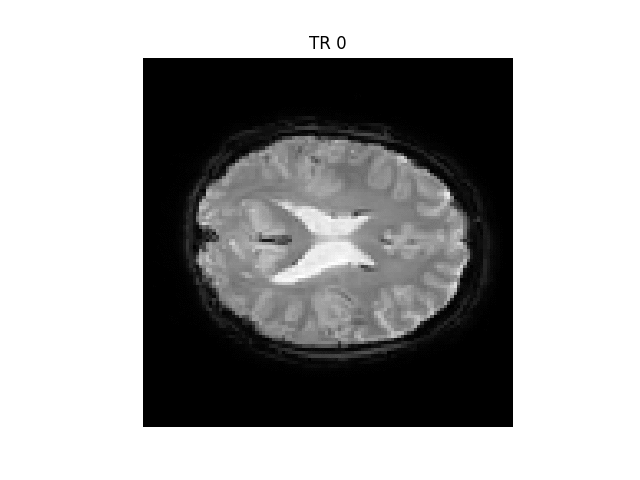

In [ ]:
from IPython.display import Image
Image(filename="motion_effect.gif")

Because head motion degrades the quality of the data, **motion correction** (also called realignment) is part of every preprocessing pipeline. Its goal is to make sure that all volumes, the 3D images collected at each time point, are spatially aligned.

Motion correction selects a **reference volume**, usually the first or the middle one, and moves all other volumes so that they match it. This uses two types of transformation:

- **Translation**: shifts along the x, y and z axes (left/right, front/back and up/down)
- **Rotation**: rotations around the three axes (pitch, roll and yaw)

![pitchrollyaw](https://www.researchgate.net/profile/Tsang_Ing_Ren/publication/279291928/figure/fig1/AS:292533185462272@1446756754388/Orientation-of-the-head-in-terms-of-pitch-roll-and-yaw-movements-describing-the-three.png)

*Image from [Arcoverde Neto et al., 2014](https://www.researchgate.net/figure/Orientation-of-the-head-in-terms-of-pitch-roll-and-yaw-movements-describing-the-three_fig1_279291928)*

Together, these transformations have **six parameters** (three translations and three rotations). This is called a **rigid body registration**. Once the parameters are estimated, each volume is **resampled** into the space of the reference volume.

Rigid body registration is a special case of **affine registration**, which can also include scaling and shearing. For motion correction, however, only translations and rotations are used.

<div class='alert alert-info'>
<b>Reflection:</b> Motion correction uses only translations and rotations (rigid body registration). Why do you think scaling and shearing are <i>not</i> applied in this step?
</div>

##### How Do We Know Which Transformations to Apply?

We cannot inspect every volume by eye and guess the right combination of translations and rotations. Instead, motion correction uses an **optimisation algorithm**. The algorithm starts with an initial guess of the six parameters and then adjusts them step by step. After each step, it uses a **cost function**, such as the sum of squared differences between the two images, to measure how well the moving image matches the reference image. The process continues until the cost function reaches its minimum, at which point the two images are as well aligned as possible.

Try it out below: move the sliders to shift the moving image until it lines up with the reference image. Notice how the value of the cost function decreases as the alignment improves.

In [ ]:
%matplotlib inline

import os
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates
import nibabel as nib
from ipywidgets import interact, FloatSlider

def build_translation_affine_2d(trans_x: float, trans_y: float) -> np.ndarray:
    """
    Build a 3x3 2D homogeneous translation matrix that maps
    reference pixel indices (i, j) -> source indices (i + trans_y, j + trans_x).

    Notes
    -----
    - We follow image-indexing convention: i = row (y), j = column (x).
    - The returned matrix A is applied to homogeneous coords [i, j, 1]^T.
    """
    A = np.array([[1.0, 0.0, float(trans_y)],
                  [0.0, 1.0, float(trans_x)],
                  [0.0, 0.0, 1.0]], dtype=float)
    return A


def apply_affine_coords_2d(A: np.ndarray, coords_last: np.ndarray) -> np.ndarray:
    """
    Apply a 3x3 affine to a field of 2D coordinates.

    Parameters
    ----------
    A : (3, 3) ndarray
        2D homogeneous affine matrix.
    coords_last : (H, W, 2) ndarray
        Coordinate grid in (i, j) order.

    Returns
    -------
    transformed : (H, W, 2) ndarray
        Transformed coordinates in (i, j) order.
    """
    H, W, _ = coords_last.shape
    ones = np.ones((H, W, 1), dtype=float)
    homo = np.concatenate([coords_last.astype(float), ones], axis=-1)            # (H, W, 3)
    flat = homo.reshape(-1, 3).T                                                # (3, H*W)
    out = (A @ flat).T[:, :2]                                                   # (H*W, 2)
    return out.reshape(H, W, 2)                                                 # (H, W, 2)


def warp_image_2d(image: np.ndarray, A: np.ndarray, order: int = 1,
                  cval: float = 0.0) -> np.ndarray:
    """
    Resample `image` at coordinates given by applying affine A to the
    target grid (backward mapping), using map_coordinates.

    Parameters
    ----------
    image : (H, W) ndarray
        Source (moving) image to be sampled.
    A : (3, 3) ndarray
        Affine mapping target grid -> source coords.
    order : int
        Spline interpolation order for map_coordinates (0=nearest, 1=linear, ...).
    cval : float
        Constant value used for points outside boundaries.

    Returns
    -------
    warped : (H, W) ndarray
        Resampled image.
    """
    H, W = image.shape
    i_coords, j_coords = np.meshgrid(np.arange(H), np.arange(W), indexing="ij")
    grid_ij = np.stack([i_coords, j_coords], axis=-1)                           # (H, W, 2)
    src_ij = apply_affine_coords_2d(A, grid_ij)                                 # (H, W, 2)
    # map_coordinates expects coords in separate arrays with shape (ndim, H, W)
    coords_for_map = np.stack([src_ij[..., 0], src_ij[..., 1]], axis=0)
    return map_coordinates(image, coords_for_map, order=order, mode="constant", cval=cval)

def apply_initial_translation(mri_slice: np.ndarray, trans_x: float, trans_y: float) -> np.ndarray:
    """Apply an initial (known) translation to create a 'moving' image."""
    A = build_translation_affine_2d(trans_x=trans_x, trans_y=trans_y)
    return warp_image_2d(mri_slice, A, order=1, cval=0.0)


def plot_affine_cost(mri_slice1: np.ndarray, mri_slice2: np.ndarray, trans_x: float = 0, trans_y: float = 0):
    """
    Interactive demo to illustrate a cost function (SSE) for 2D registration.
    - mri_slice1: moving image (will be transformed)
    - mri_slice2: reference image
    - trans_x/trans_y: user-controlled translation (columns/rows)
    """
    if mri_slice1.shape != mri_slice2.shape:
        raise ValueError("The two MRI slices must have the same dimensions.")

    # Build translation that maps target grid -> moving coords
    A = build_translation_affine_2d(trans_x=trans_x, trans_y=trans_y)
    transformed_slice = warp_image_2d(mri_slice1, A, order=1, cval=0.0)

    f, a = plt.subplots(ncols=3, figsize=(15, 5))
    a[0].imshow(transformed_slice, cmap='gray')
    a[0].set_xlabel('x', fontsize=16)
    a[0].set_ylabel('y', fontsize=16)
    a[0].set_title('Moving Image (transformed)', fontsize=18)

    a[1].imshow(mri_slice2, cmap='gray')
    a[1].set_xlabel('x', fontsize=16)
    a[1].set_ylabel('y', fontsize=16)
    a[1].set_title('Reference Image', fontsize=18)

    sse = float(np.sum((transformed_slice - mri_slice2) ** 2))
    a[2].bar(0, sse)
    a[2].set_ylim([0, max(1.0, sse * 1.1)])
    a[2].set_ylabel('SSE', fontsize=18)
    a[2].set_xlabel('Cost Function', fontsize=18)
    a[2].set_xticks([])
    a[2].set_title(f'Parameters: (tx={int(trans_x)}, ty={int(trans_y)})', fontsize=16)
    plt.tight_layout()
    plt.show()


# Load an example NIfTI and extract a 2D slice
img = nib.load(os.path.abspath('func_ref.nii.gz'))
mri_slice = img.get_fdata()[40, ...]
mri_slice1 = np.flipud(mri_slice.T)   # moving image
mri_slice2 = np.flipud(mri_slice.T)   # reference image

# Create an initially misaligned moving image by applying a random translation
rng = np.random.default_rng()
initial_trans_x = int(rng.integers(-5, 6))
initial_trans_y = int(rng.integers(-5, 6))
mri_slice1_translated = apply_initial_translation(mri_slice1, initial_trans_x, initial_trans_y)

def interactive_plot(trans_x, trans_y):
    plot_affine_cost(mri_slice1_translated, mri_slice2, trans_x, trans_y)

interact(
    interactive_plot,
    trans_x=FloatSlider(value=0, min=-30, max=30, step=1, description="tx (cols)"),
    trans_y=FloatSlider(value=0, min=-30, max=30, step=1, description="ty (rows)")
)

interactive(children=(FloatSlider(value=0.0, description='tx (cols)', max=30.0, min=-30.0, step=1.0), FloatSli…

<function __main__.interactive_plot(trans_x, trans_y)>

This demo shows how two 2D images can be aligned by minimising a cost function. Motion correction does the same in 3D, with translations and rotations along all three axes, for every volume in the 4D dataset.

##### How Do We Know If Motion Correction Worked?

The value of the cost function itself is not very informative, because it depends on the image intensities, which differ between participants and sessions. A more useful approach is to look at the **motion parameters** estimated during realignment: the three translations and three rotations over time. Large spikes in these time series show that the participant moved a lot.

Inspecting six time series for every scan quickly becomes cumbersome, however. We therefore often summarise head motion with a single number per volume: the **framewise displacement (FD)**. FD is the sum of the absolute changes in the six motion parameters from one volume to the next. The rotations are first converted to millimetres, so that they are comparable with the translations. High FD values indicate large head movements.

In the next cell, we compare FD before and after motion correction to see how well the procedure removed the effects of motion.

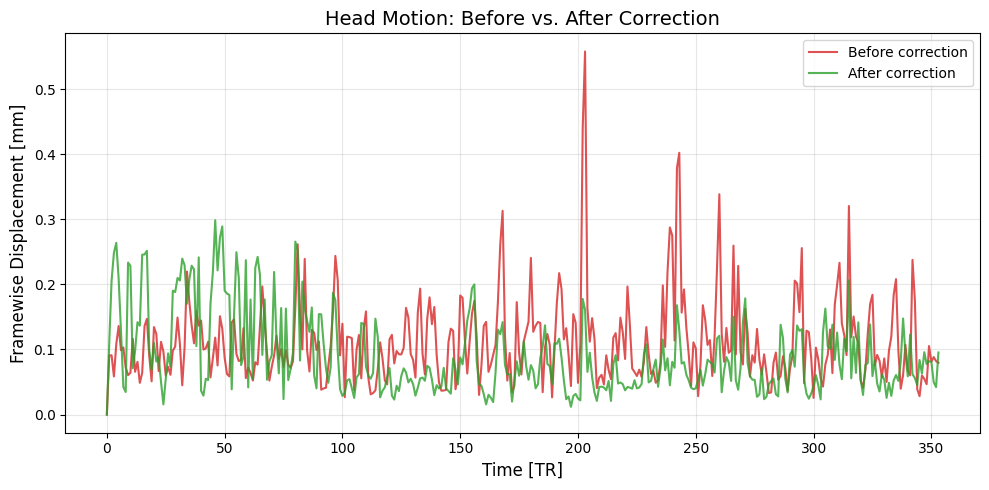

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Load framewise displacement (FD) values
fd_before = np.loadtxt(os.path.abspath('fd_before.txt'))
fd_after = np.loadtxt(os.path.abspath('fd_after.txt'))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(fd_before, label='Before correction', color='tab:red', alpha=0.8)
plt.plot(fd_after, label='After correction', color='tab:green', alpha=0.8)

plt.xlabel('Time [TR]', fontsize=12)
plt.ylabel('Framewise Displacement [mm]', fontsize=12)
plt.title('Head Motion: Before vs. After Correction', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<div class='alert alert-info'>
<b>Reflection:</b> As you can see above, the large spike is gone after motion correction. However, there seems to be <i>more</i> movement at the beginning of the scan after motion correction. Why do you think that is?
</div>

<details>
<summary><b>Solution</b> (click to expand)</summary>

Motion correction aligns all volumes to a chosen **reference volume** (often the first or the middle one). If the participant's head was in a different position at the start of the scan than in the reference volume, the early volumes need to be moved further to match it. This apparent extra movement does not mean that the participant moved more, but simply reflects the adjustment needed to align the early volumes with the reference.

</details>

fMRIPrep produces a detailed report for each dataset, including a summary of head motion. The figure below shows an excerpt from this report:

In [ ]:
Image(filename="figure_fMRIPrep_movement.png")

The figure above shows that motion correction can be very effective at reducing movement artefacts. However, it is not perfect. If a participant moves too much, the algorithm may fail to correct the data, and those scans may need to be excluded from the analysis. Even after correction, some **residual motion effects** remain. For this reason, the motion parameters are usually included as **confound regressors** in the GLM. We will return to this in Section 3.

#### 3. Susceptibility Distortion Correction

The BOLD signal is sensitive to the magnetic field of the scanner. Because this field is never perfectly uniform, it produces **geometric distortions** in the images. These distortions are strongest in the frontal and temporal lobes.

There are several ways to correct these distortions, but all of them require additional images besides the main functional run. The **fieldmap method** acquires a separate map of the inhomogeneities in the magnetic field. The **topup method** acquires a short series of images with the **opposite phase-encoding direction**. At the UvA imaging centre, the topup method is commonly used: if the main fMRI run is acquired in the anterior-to-posterior direction, a few volumes are also acquired in the posterior-to-anterior direction just before the run. The distortions in the two sets of images go in opposite directions, so by combining them, we can estimate the distortions and correct them.

Images acquired with opposite phase-encoding directions look like this:

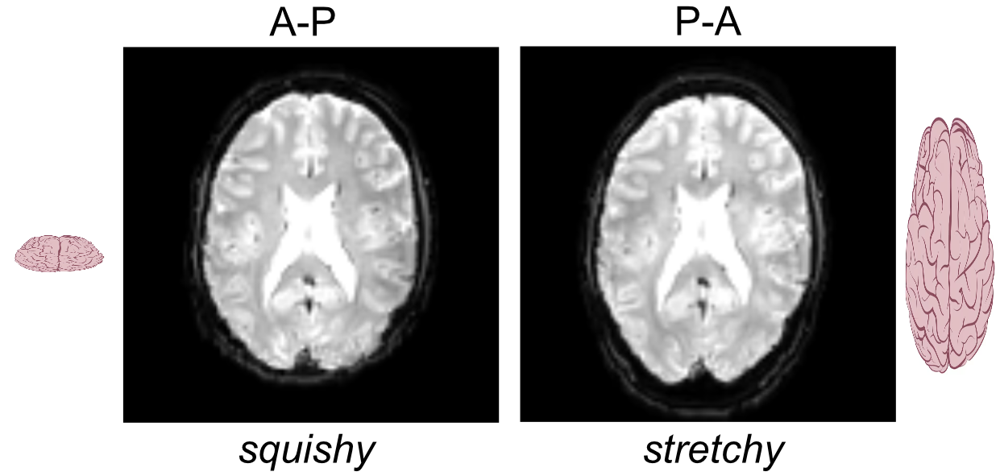

In [ ]:
Image(filename="figure_susceptibility_illustration.png")

The opposite distortions in the two images can be used to compute a **fieldmap**. The fieldmap below shows where the image needs to be shifted in the phase-encoding direction (red) or in the opposite direction (blue) to correct the distortions. This is how we go from squashed and stretched images to images that match the anatomy.

We will not cover the physics or the algorithms in detail, as this is not an MRI physics course. However, it is important that you can **recognise susceptibility distortions** and understand what the correction achieves.

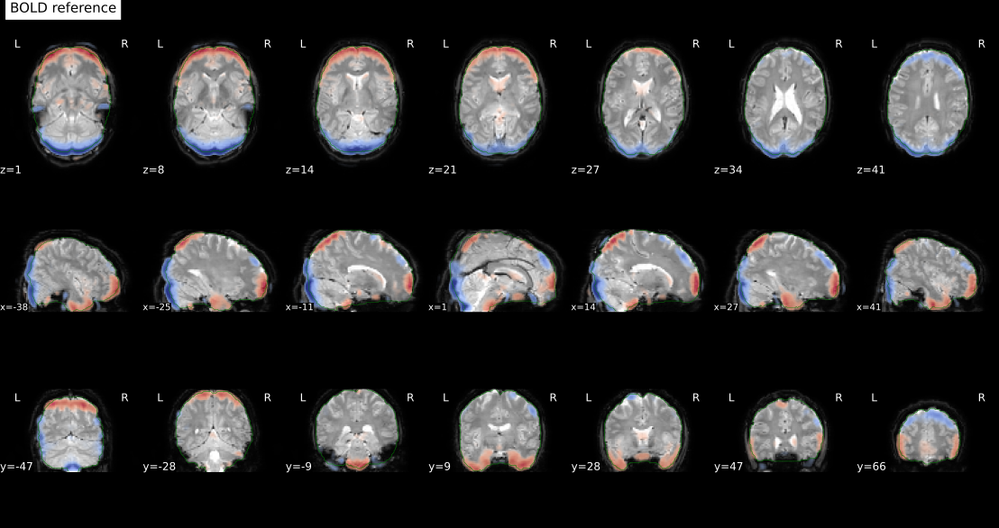

In [ ]:
Image(filename="figure_fMRIPrep_fieldmap.png")

The displacements estimated in the fieldmap are applied to the functional images to correct the distortions. After correction, the functional images should match the anatomical image more closely.

##### What Should You Check?

When you assess the quality of your data, always compare the images before and after susceptibility distortion correction. If the correction worked, the functional images align better with the anatomy, and areas that were squashed or stretched look more normal. If it failed, distortions remain. This can happen when the participant moved a lot, or when the metadata contain an error, for example the wrong phase-encoding direction. In severe cases, the data may need to be excluded from the analysis.

<div class='alert alert-info'>
<b>Reflection:</b> Imagine you are planning a new fMRI study. Should you acquire an image with the opposite phase-encoding direction before <b>each fMRI run</b>, or only <b>once per session</b>? What are the advantages and disadvantages of each approach?
</div>

<details>
<summary><b>Solution</b> (click to expand)</summary>

**One image before each run** gives a more accurate correction, because the distortions are estimated just before the run. Movement of the participant or changes in the magnetic field between runs therefore matter less. The downside is that it adds scan time to every run.

**One image per session** saves time, especially in long protocols, and reduces the burden on the participant. However, it assumes that the distortions stay the same throughout the session. This assumption breaks down if the participant moves a lot or if the magnetic field changes over time.

</details>

#### 4. Slice Timing Correction

In fMRI, the brain is scanned one **slice** at a time. Because the slices are acquired one after the other, each slice is measured at a slightly different moment within the same repetition time (TR), so some slices are recorded earlier than others. **Slice timing correction** adjusts the data so that all slices are aligned in time, as if they had been acquired at the same moment.

To see why this matters, we simulate the time courses of two voxels: one in a slice at the top of the brain and one in a slice at the bottom.

top voxel time course (first 10 points): [0.05374851 0.29926766 0.6566312  0.96539708 0.93171828 0.9806634
 1.11305489 0.88983756 0.54491491 0.3673501 ]
bottom voxel time course (first 10 points): [0.02719192 0.35650863 0.68750356 0.90581038 0.80470276 0.89763068
 0.99397322 0.85180877 0.6307032  0.68570332]


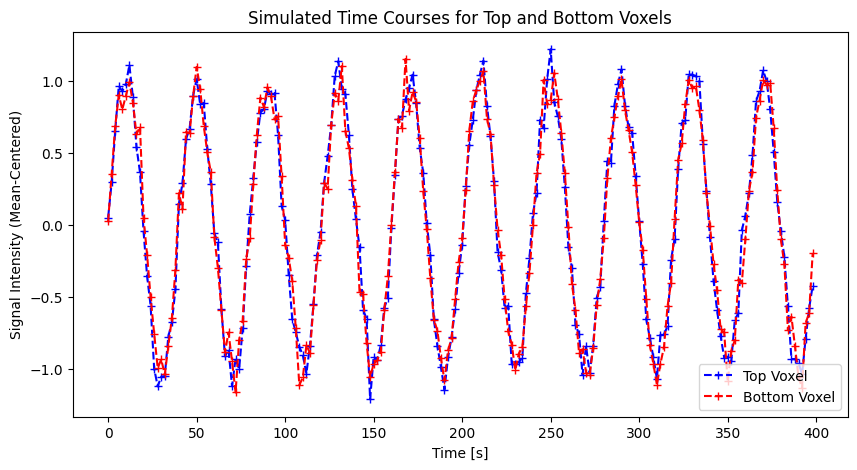

In [ ]:
# Simulation parameters
n_timepoints = 200  # Number of time points
TR = 2.0            # Repetition time in seconds
np.random.seed(42)  # For reproducible results
slice_times = np.arange(0, n_timepoints * TR, TR)


# Define simulated voxel time courses with low-frequency components and noise
def simulate_time_course(n_timepoints, frequency=0.05, noise_level=0.1):
    time = np.arange(n_timepoints)
    # Simulate a low-frequency oscillation and add random noise
    time_course = np.sin(2 * np.pi * frequency * time) + noise_level * np.random.randn(n_timepoints)
    # Mean center the time course
    time_course = time_course - np.mean(time_course)
    return time_course

# Generate simulated time courses for 'top' and 'bottom' voxels
time_courses = []
for name in ['top', 'bottom']:
    time_course = simulate_time_course(n_timepoints)
    time_courses.append({
        'name': name,
        'time_course': time_course
    })

# Print out the simulated time courses
for tc in time_courses:
    print(f"{tc['name']} voxel time course (first 10 points):", tc['time_course'][:10])


# Plotting the simulated time courses
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# Plot the time courses for 'top' and 'bottom' voxels
ax.plot(slice_times, time_courses[0]['time_course'], label='Top Voxel', color='blue', linestyle='--', marker='+')
ax.plot(slice_times, time_courses[1]['time_course'], label='Bottom Voxel', color='red', linestyle='--', marker='+')

# Set titles and labels
ax.set_title('Simulated Time Courses for Top and Bottom Voxels')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Signal Intensity (Mean-Centered)')
ax.legend()

# Display the plot
plt.show()

In the plot above, we drew both time courses as if all slices had been acquired at the start of each TR. In reality, the slices were acquired at different times. In the next plot, we take this into account: the top voxel is acquired at the start of each TR, and the bottom voxel almost a full TR later. The grey lines mark the times at which the bottom voxel was acquired.

In [ ]:
# Simulation parameters
n_timepoints = 200
TR = 2.0  # seconds
n_z_slices = 30  # Hypothetical number of slices for simulation
time_for_single_slice = TR / n_z_slices

# Start of each TR, and the acquisition times of the top and bottom voxels for the first 5 TRs (10 seconds)
slice_times = np.arange(n_timepoints) * TR
slice_times_bottom = slice_times[:5] + (n_z_slices - 1) * time_for_single_slice  # bottom slice: acquired last
slice_times_top = slice_times[:5] + 0 * time_for_single_slice                    # top slice: acquired first

# Plotting the time courses for the first 10 seconds
plt.figure(figsize=(10, 5))
plt.plot(slice_times_bottom, time_courses[1]['time_course'][:5], label='Bottom Voxel', color='red', linestyle='--', marker='+')
plt.plot(slice_times_top, time_courses[0]['time_course'][:5], label='Top Voxel', color='blue', linestyle='--', marker='+')

# Add labels and legend
plt.xlabel('Time [s]')
plt.ylabel('Signal Intensity (Mean-Centered)')
plt.legend()

# Add vertical lines for each acquisition time of the bottom voxel
for slice_time in slice_times_bottom:
    plt.axvline(slice_time, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

plt.title("Simulated Time Courses for the First 10 Seconds with Slice Acquisition Timing")
plt.show()

The bottom voxel was acquired almost a full TR later than the top voxel. If we analysed both time courses as if they had been measured at the same time, the response in the bottom voxel would appear delayed.

One solution is to estimate what the signal of the top voxel would have been **if it had been acquired at the same time as the bottom voxel**. We can do this by **interpolation**: we draw a straight line between two consecutive measurements of the top voxel, and read off the value of this line at the acquisition time of the bottom voxel. The code below does this for one time point:

In [ ]:
# Two consecutive measurements of the top voxel
top_x1, top_y1 = slice_times_top[0], time_courses[0]['time_course'][0]
top_x2, top_y2 = slice_times_top[1], time_courses[0]['time_course'][1]

# First acquisition time of the bottom voxel, which lies between the two measurements of the top voxel
bottom_x1 = slice_times_bottom[0]

def calculate_new_y(x, top_x1, top_y1, top_x2, top_y2):
    """Return the slope of the line through two points, and the value of that line at x."""
    slope = (top_y2 - top_y1) / (top_x2 - top_x1)
    intercept = top_y1 - slope * top_x1
    y = slope * x + intercept
    return slope, y

slope, new_y = calculate_new_y(bottom_x1, top_x1, top_y1, top_x2, top_y2)

# Plotting the line between the two measurements of the top voxel, and the interpolated value
plt.plot([top_x1, top_x2], [top_y1, top_y2], color='blue', marker='x', linestyle='--', label='Top voxel (measured)')
plt.plot(bottom_x1, new_y, color='red', marker='x', markersize=10, linestyle='none', label='Top voxel (interpolated)')
plt.axvline(bottom_x1, color='black', linewidth=0.5, alpha=0.5)
plt.annotate('Interpolated Point', (bottom_x1, new_y), textcoords="offset points", xytext=(-35, -20), ha='center')
plt.xlabel('Time [s]')
plt.ylabel('Signal Intensity')
plt.legend()
plt.show()

We could repeat this for every time point by hand, but libraries such as **SciPy** have built-in functions for interpolation. In the code below, we use **linear interpolation** from SciPy, which draws straight lines between consecutive measurements and evaluates them at the times we ask for. Here, we use it to estimate the signal of the top voxel at the acquisition times of the bottom voxel.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Simulation parameters
n_timepoints   = 200
TR             = 2.0         # seconds
n_z_slices     = 30          # number of slices
dt_slice       = TR / n_z_slices  # time between successive slice acquisitions within a TR

# We'll visualise only the first 10 s to keep the plot readable
t_window       = 10.0
n_pts_window   = int(t_window / TR)  # number of whole TRs in the window (here: 5)

# Acquisition times (start of each TR)
t_tr           = np.arange(n_timepoints) * TR

# Slice acquisition times for two example voxels:
# - "top" voxel acquired at the start of each TR
# - "bottom" voxel acquired near the end of each TR
t_top          = t_tr[:n_pts_window] + 0 * dt_slice
t_bottom       = t_tr[:n_pts_window] + (n_z_slices - 1) * dt_slice

# Simulating the time courses: both voxels follow the same slow sinusoid, plus a little noise,
# but each voxel samples it at its own acquisition times
rng = np.random.default_rng(42)
def true_signal(t):
    return np.sin(2 * np.pi * (t / 20.0))
top_signal     = true_signal(t_tr) + 0.02 * rng.standard_normal(t_tr.shape)
bottom_signal  = true_signal(t_tr + (n_z_slices - 1) * dt_slice) + 0.02 * rng.standard_normal(t_tr.shape)

# Take the first few samples corresponding to our 10 s window
y_top_window     = top_signal[:n_pts_window]
y_bottom_window  = bottom_signal[:n_pts_window]

# Interpolating the top voxel at the acquisition times of the bottom voxel
# (linear interpolation; we use one extra measurement of the top voxel, so that the last bottom time is covered)
top_to_bottom = interp1d(t_tr[:n_pts_window + 1], top_signal[:n_pts_window + 1], kind="linear")

y_top_interp_at_bottom = top_to_bottom(t_bottom)

# Plotting the measured bottom voxel and the interpolated top voxel
plt.figure(figsize=(10, 5))
plt.plot(t_bottom, y_bottom_window, label='Bottom voxel (measured)', linestyle='--', marker='+', color='red')
plt.plot(t_bottom, y_top_interp_at_bottom, label='Top voxel (interpolated to bottom times)', linestyle='--', marker='+', color='blue')

# Vertical lines to show each (bottom) slice time within the window
for tb in t_bottom:
    plt.axvline(tb, color='k', linestyle='-', linewidth=0.5, alpha=0.4)

plt.xlabel('Time [s]')
plt.ylabel('Signal intensity (mean-centered)')
plt.title('Slice-timing alignment via linear interpolation')
plt.legend()
plt.tight_layout()
plt.show()

In practice, you will almost never need to perform slice timing correction yourself. Most neuroimaging software packages include functions for this step, and fMRIPrep applies it automatically if the slice timing information is available in the metadata.

However, slice timing correction is **more error-prone than many other preprocessing steps**. Mistakes are hard to spot by looking at the data, but they can seriously affect your results. Always check that the slice timing information in the BIDS metadata matches the protocol of the scanner.

#### 5. Coregistration

In most fMRI studies, we acquire one or more high-resolution **anatomical images** (T1-weighted and/or T2-weighted) in the same session as the functional scans. These images show the anatomy in fine detail, which helps, for example, to define brain regions of interest. To use this information, we need to align the functional images with the anatomical image. This step is called **coregistration**.

Here is an example from the same participant:

In [ ]:
Image(filename="figure_T1vsEPI.png")

The anatomical image has a much higher resolution and a different contrast. The functional image (EPI) has a lower resolution and shows some distortions, but it contains the BOLD signal we want to analyse.

To align the two images, we use the same principle as in motion correction: an optimisation algorithm adjusts the parameters of an **affine transformation** step by step, until the functional image matches the anatomical image as well as possible.

<div class='alert alert-info'>
<b>Reflection:</b> In the motion correction demo above, we aligned two images by minimising the sum of squared errors (SSE). For coregistration, we usually use a different cost function: <b>mutual information (MI)</b>. Why do you think the SSE is not suitable for aligning a T1-weighted anatomical image with a BOLD fMRI image?
</div>

#### 6. Normalisation

The final alignment step is **normalisation**: transforming each participant's brain images into a **common reference space**. This step is essential for group analyses. Without it, the same voxel coordinates would refer to different brain locations in different participants, so we could not compare them.

The figure below shows the same voxel coordinates in the native anatomical space of several participants:

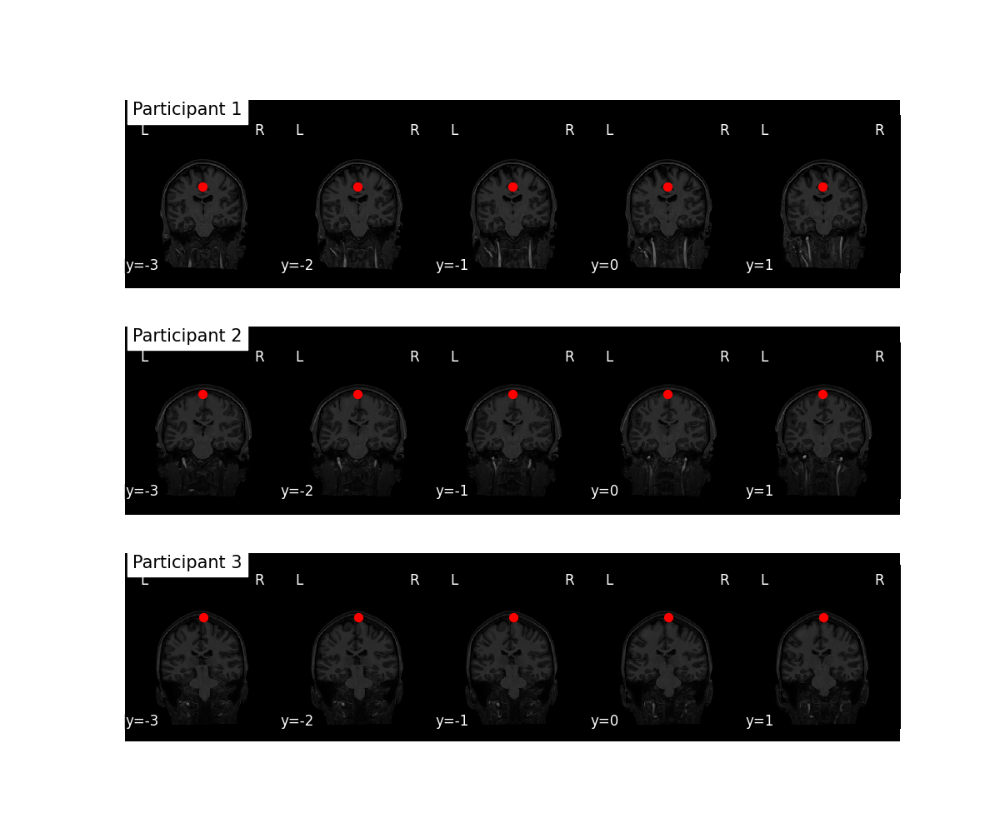

In [ ]:
Image(filename="figure_anatomy_comparison.png")

The voxel lies in a different brain region in each participant, and in Participant 3 it is not even inside the brain. Comparing the activity in this voxel across participants would be like comparing apples and oranges. Normalisation makes sure that the same coordinates refer to the same anatomical location in everyone.

##### The MNI152 Space

The most widely used template is the **MNI152** template, created by the Montreal Neurological Institute (MNI) and the International Consortium for Brain Mapping (ICBM). It is based on the average of 152 anatomical scans. Several versions exist, such as **MNI152NLin2009cAsym**, the default in fMRIPrep. This version, from 2009, was created with non-linear registration and keeps the natural asymmetry between the two hemispheres. For the analysis itself, the exact version rarely matters, as long as all participants are transformed to the same space. For reporting and for comparisons across studies, however, you should always state which template you used.

##### How Do We Normalise Data?

Normalisation uses a **non-linear transformation**, which is more flexible than the affine transformations used in motion correction and coregistration. Affine transformations can translate, rotate, scale and shear an image, but human brains differ in shape and size in ways that these global transformations cannot capture. Non-linear transformations can stretch and compress the image locally, so that each participant's anatomy matches the template more closely.

In practice, the participant's anatomical image is first aligned to the MNI template. The resulting transformation is then applied to the functional images, which brings them into the same space.

<div class='alert alert-info'>
<b>Reflection:</b> Normalisation is usually performed on skull-stripped anatomical images rather than on the raw scans. Why do you think removing the skull and other non-brain tissue makes normalisation more accurate?
</div>

#### 7. Spatial Smoothing

Even after careful preprocessing, small misalignments remain between the brains of different participants. To reduce their impact, and to reduce noise, we usually apply **spatial smoothing**: we average the signal of each voxel with that of its neighbours. This increases the signal-to-noise ratio and makes the data more comparable across participants.

Smoothing is performed with a **Gaussian kernel**. The size of the kernel is described by its **full width at half maximum (FWHM)**: the width of the Gaussian curve at half of its peak value, in millimetres. The larger the FWHM, the more the signal of each voxel is blended with that of its neighbours.

In the demo below, you can see how smoothing changes the appearance of a functional image:

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import image
import ipywidgets as widgets

# Load the functional image (BOLD reference)
boldref_filename = os.path.abspath('sub-03_ses-1_task-face_run-1_space-T1w_boldref.nii.gz')
func_img = image.load_img(boldref_filename)  # niimg

# Helper: extract a mid axial slice for display
def mid_axial_slice(np3d):
    x, y, z = np3d.shape
    sl = z // 2
    return np.flipud(np3d[:, :, sl].T)

# Update + plot based on FWHM (in mm)
def update_plot(fwhm):
    # Apply Gaussian smoothing with specified FWHM (mm).
    # If fwhm == 0, just show the original.
    func_smoothed = image.smooth_img(func_img, fwhm=fwhm) if fwhm > 0 else func_img

    # Fetch data for plotting
    orig_slice = mid_axial_slice(func_img.get_fdata())
    smooth_slice = mid_axial_slice(func_smoothed.get_fdata())

    # Plot
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(orig_slice, cmap='gray')
    plt.title('Functional Image (original)')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(smooth_slice, cmap='gray')
    plt.title(f'Functional Image (smoothed, FWHM = {fwhm:.1f} mm)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Interactive slider for FWHM (mm)
sigma_slider = widgets.FloatSlider(
    value=2.0, min=0.0, max=10.0, step=0.1,
    description='FWHM (mm):', continuous_update=True
)

widgets.interactive(update_plot, fwhm=sigma_slider)

Biological signals are spread out over several neighbouring voxels, whereas random noise differs from one voxel to the next. Averaging neighbouring voxels therefore keeps the signal but reduces the noise. Let's see whether this works in practice: we add random noise to the image, smooth the noisy image, and measure how much the noise is reduced.

In [ ]:
import numpy as np
from nilearn import image, masking
import nibabel as nib

def add_noise_img(niimg, noise_level=0.1, random_state=None):
    """
    Add Gaussian noise to a NIfTI image and return a new NIfTI (same affine/header).
    """
    rng = np.random.default_rng(random_state)
    data = niimg.get_fdata()
    noisy = data + rng.normal(loc=0.0, scale=noise_level, size=data.shape)
    return image.new_img_like(niimg, noisy)

def compute_noise_metrics(niimg, brain_mask_img=None):
    """
    Compute a simple noise metric: standard deviation of voxel values.
    If a brain mask is provided, compute within-mask std.
    """
    data = niimg.get_fdata()
    if brain_mask_img is not None:
        mask = brain_mask_img.get_fdata().astype(bool)
        vals = data[mask]
    else:
        vals = data.ravel()
    return float(np.std(vals))

def quantifying_noise_reduction(noisy_img, smoothed_img, brain_mask_img=None):
    """
    Print and return percent noise reduction between noisy and smoothed images.
    """
    noise_before = compute_noise_metrics(noisy_img, brain_mask_img)
    noise_after  = compute_noise_metrics(smoothed_img, brain_mask_img)
    percent_reduction = 100.0 * (noise_before - noise_after) / (noise_before + 1e-12)
    print(f'Noise before smoothing: {noise_before:.4f}')
    print(f'Noise after  smoothing: {noise_after:.4f}')
    print(f'Noise reduction: {percent_reduction:.2f}%')
    return percent_reduction

# (1) Optional: compute a brain mask so the metric focuses on brain voxels
brain_mask_img = masking.compute_epi_mask(func_img)

# (2) Create a noisy copy of the functional image
noisy_img = add_noise_img(func_img, noise_level=0.5, random_state=42)

# (3) Smooth the (noisy) image using a Gaussian kernel with FWHM in millimetres
func_smoothed = image.smooth_img(noisy_img, fwhm=2.0)

# (4) Quantify noise reduction (within brain mask)
_ = quantifying_noise_reduction(noisy_img, func_smoothed, brain_mask_img=brain_mask_img)

<div class='alert alert-warning'>
<b>ToDo</b> Choosing a smoothing kernel:
Find the smallest Gaussian smoothing kernel (FWHM in mm) that reduces the noise by at least 5%, so that the data become less noisy while keeping as much spatial detail as possible.

✅ Tip: Define a range of candidate FWHM values (e.g. 0, 1, 2, ..., 10 mm) and compute the noise reduction for each value with the functions above. Then choose the smallest FWHM for which the noise reduction is at least 5%.
</div>

In [ ]:
# YOUR CODE HERE

##### The Impact of Smoothing on Test Statistics

So far, we have seen that spatial smoothing reduces noise by averaging neighbouring voxels. This has a direct effect on the GLM. Recall the test statistic:

$$
t = \frac{\hat{\beta}}{\hat{\sigma}}
$$

where $\hat{\beta}$ is the estimated effect size (the signal) and $\hat{\sigma}$ is its estimated standard error (the noise).

To make the link between preprocessing and statistics concrete, we run a simulation. We create a small 4D dataset with 200 time points. Inside a small spherical region of interest (ROI), the signal follows a simple task design with blocks of stimulation and rest. Everywhere else, the signal is just random noise. We then fit a GLM with one task regressor and an intercept to every voxel, and compute the t-value for the task effect. We repeat this analysis after smoothing the data with kernels of 0, 2, 4, 6 and 8 mm FWHM.

When you look at the results, pay attention to two things:

1. **Inside the ROI**, smoothing reduces the noise, so the standard error $\hat{\sigma}$ becomes smaller and the t-values increase.
2. **Outside the ROI**, smoothing spreads the signal into neighbouring voxels, so the t-values just outside the ROI increase as well.

This illustrates the trade-off of smoothing: it makes the analysis more **sensitive** to real effects, but it blurs the spatial detail, which makes it harder to locate small effects precisely.

In [ ]:
# Simulation: how spatial smoothing affects GLM t-statistics

import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import image

# 1) Building a synthetic 4D dataset
rng = np.random.default_rng(42)

# Spatial grid (in mm): 3 mm isotropic voxels
vx = 3.0
nx, ny, nz = 48, 48, 32
affine = np.diag([vx, vx, vx, 1.0])

# Time dimension
T = 200
TR = 2.0  # seconds

# Design: simple boxcar (on/off blocks) + intercept
block_len = 20
on = np.tile(np.r_[np.ones(block_len), np.zeros(block_len)], T // (2 * block_len))
X = np.c_[np.ones(T), on]  # [intercept, task]
# Normalise task regressor for clarity (optional but common)
X[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()

# True effect β inside a spherical ROI, zero elsewhere
beta_task = 1.0  # amplitude of task effect (arbitrary units)
beta_intercept = 100.0  # baseline signal level (arbitrary units)

# Make a spherical ROI (radius ~ 3 voxels)
cx, cy, cz = nx // 2, ny // 2, nz // 2
xg, yg, zg = np.meshgrid(np.arange(nx), np.arange(ny), np.arange(nz), indexing="ij")
roi = ( (xg - cx)**2 + (yg - cy)**2 + (zg - cz)**2 ) <= (3.0**2)

# Noise parameters
sigma_noise = 2.0  # Gaussian noise SD
# Optional: add a tiny AR(1)-like temporal autocorrelation by filtering
def ar1_like(ts, rho=0.3):
    y = np.zeros_like(ts)
    for t in range(len(ts)):
        y[t] = (rho * y[t-1] if t > 0 else 0.0) + ts[t]
    return y

# Generate 4D data: Y(x,y,z,t) = β0 + β1*task(t) (inside ROI) + noise
Y = np.empty((nx, ny, nz, T), dtype=np.float32)
task_ts = X[:, 1]

for ix in range(nx):
    for iy in range(ny):
        # vectorised over z for some speed
        mask_line = roi[ix, iy, :]
        # baseline
        baseline_line = np.full((nz, T), beta_intercept, dtype=np.float32)
        # task effect only in ROI voxels
        effect_line = np.zeros((nz, T), dtype=np.float32)
        effect_line[mask_line, :] = beta_task * task_ts  # same effect for all ROI voxels
        # noise
        noise_line = rng.normal(0.0, sigma_noise, size=(nz, T))
        # add light AR(1) temporal structure
        for k in range(nz):
            noise_line[k, :] = ar1_like(noise_line[k, :], rho=0.3)
        Y[ix, iy, :, :] = baseline_line + effect_line + noise_line

# Wrap as 4D NIfTI
img = nib.Nifti1Image(Y, affine)

# 2) Fitting the GLM (OLS) to every voxel
# Precompute OLS helper matrices
X_ = X  # (T x 2)
XtX_inv = np.linalg.inv(X_.T @ X_)           # (2 x 2)
pinv_X = XtX_inv @ X_.T                      # (2 x T)
C = np.array([0, 1.0])                       # contrast for the task regressor

def fit_glm_and_t(nifti_img):
    """Return t-map for the task contrast."""
    data = nifti_img.get_fdata().astype(np.float32)  # (nx, ny, nz, T)
    # Reshape to 2D: V x T
    V = np.prod(data.shape[:3])
    Y2D = data.reshape(V, T)
    # β̂ (V x 2)
    beta_hat = Y2D @ pinv_X.T
    # Residuals
    Y_fit = beta_hat @ X_.T
    resid = Y2D - Y_fit
    dof = T - X_.shape[1]
    # σ̂^2 per voxel
    sigma2 = (resid**2).sum(axis=1) / max(dof, 1)
    # Var(β̂) = σ̂^2 * (X'X)^{-1}; for contrast c, Var(c'β̂) = σ̂^2 * c'(X'X)^{-1}c
    c_var = C @ XtX_inv @ C  # scalar
    # t = c'β̂ / sqrt(σ̂^2 * c'(X'X)^{-1}c)
    num = (beta_hat @ C)                    # (V,)
    den = np.sqrt(np.maximum(sigma2 * c_var, 1e-12))
    tvals = num / den
    return tvals.reshape(data.shape[:3])

# 3) Smoothing with different kernel sizes (FWHM) and refitting the GLM
fwhm_list = [0, 2, 4, 6, 8]  # in mm
mean_t_in_roi = []
mean_abs_t_outside = []
maps = {}

for f in fwhm_list:
    # Smooth each volume (Nilearn handles 4D)
    smoothed = image.smooth_img(img, fwhm=f) if f > 0 else img
    tmap = fit_glm_and_t(smoothed)
    maps[f] = tmap
    # Metrics: signal vs. background
    roi_mask = roi
    bg_mask = ~roi_mask
    mean_t_in_roi.append(np.nanmean(tmap[roi_mask]))
    mean_abs_t_outside.append(np.nanmean(np.abs(tmap[bg_mask])))

# 4) Plotting the t-values against the kernel size
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(fwhm_list, mean_t_in_roi, marker='o')
plt.xlabel('FWHM (mm)')
plt.ylabel('Mean t in ROI')
plt.title('Sensitivity increases with moderate smoothing')
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(fwhm_list, mean_abs_t_outside, marker='o')
plt.xlabel('FWHM (mm)')
plt.ylabel('Mean |t| outside ROI')
plt.title('Apparent background t (blurring/spillover)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Show axial mid-slice t-maps for visual intuition
midz = nz // 2
ncols = len(fwhm_list)
plt.figure(figsize=(2.8*ncols, 3))
for i, f in enumerate(fwhm_list, 1):
    sl = maps[f][:,:,midz].T
    plt.subplot(1, ncols, i)
    plt.imshow(np.flipud(sl), cmap='coolwarm', vmin=-6, vmax=6)
    plt.title(f'FWHM={f} mm')
    plt.axis('off')
plt.suptitle('Task t-maps (axial mid-slice): more smoothing gives higher t-values, but more blurring', y=1.02)
plt.tight_layout()
plt.show()

# 5) Printing the mean t-values for each kernel size
print("Mean t in ROI by FWHM:", dict(zip(fwhm_list, [f"{v:.2f}" for v in mean_t_in_roi])))
print("Mean |t| outside ROI by FWHM:", dict(zip(fwhm_list, [f"{v:.2f}" for v in mean_abs_t_outside])))

<div class='alert alert-warning'>
<b>ToDo</b> Quantifying the effect of smoothing:
Use the dictionary <code>maps</code> (with the FWHM values as keys and the t-maps as values) and the boolean ROI mask <code>roi</code> from the simulation above.
<ol>
<li>Compute the mean t-value inside the ROI for FWHM = 0 mm and FWHM = 6 mm.</li>
<li>Compute the mean absolute t-value outside the ROI for the same two kernel sizes.</li>
<li>Based on your results, explain in 2–3 sentences how smoothing affects the test statistic inside the ROI and the apparent activation outside the ROI.</li>
</ol>
</div>

In [ ]:
# YOUR CODE HERE

This simulation shows how spatial smoothing links preprocessing to the statistics of the GLM. By averaging neighbouring voxels, smoothing reduces the noise and the standard error $\hat{\sigma}$, which increases the t-values in regions with a true effect. At the same time, it blurs the signal, which increases the apparent activation outside these regions and reduces spatial precision. More generally, **preprocessing choices shape the error term, and therefore the statistical conclusions we draw**.

**Brief recap**: In this section, you learned that:
- Preprocessing reduces unwanted variance in the BOLD signal and aligns the data in space and time before we fit the GLM
- Motion correction aligns all volumes to a reference volume with a rigid body transformation (3 translations and 3 rotations), found by an optimisation algorithm that minimises a cost function. Framewise displacement (FD) summarises head motion in a single number per volume
- Susceptibility distortion correction uses images with the opposite phase-encoding direction, or a fieldmap, to undo geometric distortions caused by inhomogeneities in the magnetic field
- Slice timing correction uses interpolation to estimate what each slice would have measured if all slices had been acquired at the same time
- Coregistration aligns the functional images with the participant's anatomical image, usually with mutual information as the cost function, because the two types of image have different contrasts
- Normalisation maps each brain onto a common template, such as MNI152, so that the same coordinates refer to the same brain region in every participant
- Spatial smoothing averages each voxel with its neighbours. This reduces noise and increases t-values in truly active regions, but it also blurs the activation and reduces spatial precision

---
## Section 3: Nuisance Regression and Prewhitening
---

Preprocessing removes much of the noise in fMRI data, but some always remains. In this section, we deal with the remaining noise in the GLM itself. We use data from a participant who viewed pictures of smiling and neutral faces (dataset [ds003965](https://openneuro.org/datasets/ds003965/versions/1.0.0) on OpenNeuro), preprocessed with fMRIPrep. Occasionally, the participant rated a face and responded with a button press.

#### Adding Motion Confounds to the GLM

As we saw in Section 2, motion correction does not remove all effects of head motion. fMRIPrep saves the motion parameters it estimated during realignment in the confounds file: three translations (`trans_x`, `trans_y`, `trans_z`) and three rotations (`rot_x`, `rot_y`, `rot_z`). We add these 6 parameters to the design matrix, together with their **temporal derivatives** (the change from one volume to the next, `*_derivative1`), which capture the effect of sudden movements. This gives 12 motion regressors in total.

We build two design matrices: one with only the task and drift regressors, and one that also includes the 12 motion regressors.

trial_type
smiling     20
neutral     20
rating       5
response     5
Name: count, dtype: int64
    trans_x   trans_y   trans_z         rot_x     rot_y     rot_z  \
0 -0.000043 -0.152561 -0.000008 -2.281060e-23 -0.000291  0.000421   
1  0.000023 -0.050819 -0.027347  0.000000e+00  0.000048  0.000000   
2  0.000028 -0.021312 -0.016438  1.260200e-04  0.000048  0.000000   
3  0.000054 -0.104531 -0.000077 -5.805540e-04  0.000490  0.000000   
4  0.000004 -0.045289 -0.008790 -2.532180e-04 -0.000084  0.000170   

   trans_x_derivative1  trans_y_derivative1  trans_z_derivative1  \
0             0.000000             0.000000             0.000000   
1             0.000066             0.101742            -0.027339   
2             0.000005             0.029507             0.010909   
3             0.000026            -0.083219             0.016361   
4            -0.000050             0.059242            -0.008713   

   rot_x_derivative1  rot_y_derivative1  rot_z_derivative1  
0       0.000000e+

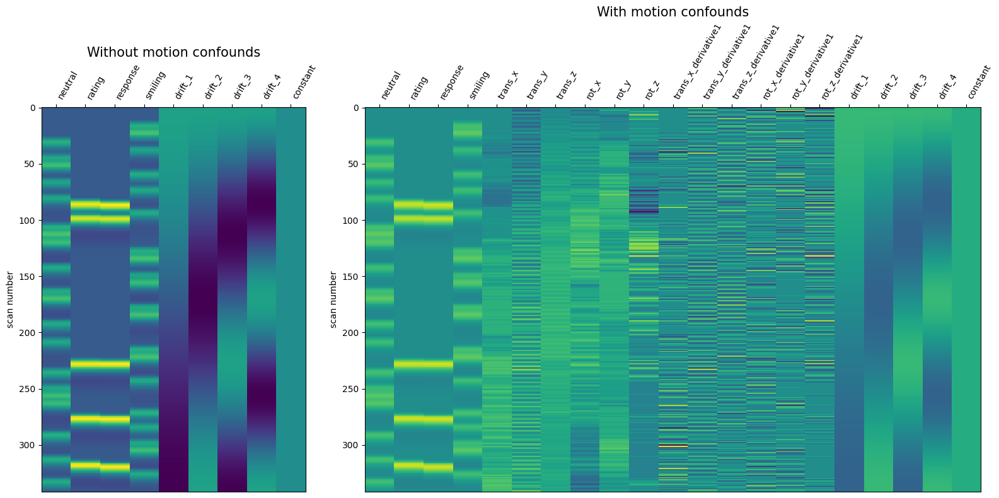

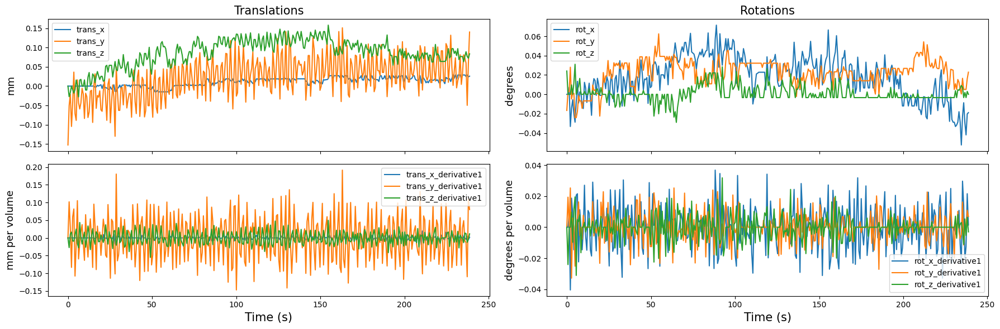

In [ ]:
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix

func_file = 'sub-03_ses-1_task-face_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz'
confounds_file = 'sub-03_ses-1_task-face_run-1_desc-confounds_timeseries.tsv'
events_file = 'sub-03_ses-1_task-face_run-1_events.tsv'

# Timing of the scan: repetition time (in seconds) and number of volumes
t_r = 0.7
n_volumes = nib.load(func_file).shape[-1]
frame_times = np.arange(n_volumes) * t_r

# Loading the events. Each face has its own trial_type (e.g. '00STIM117smiling'),
# so we group the face trials by their expression: smiling or neutral.
events = pd.read_csv(events_file, sep='\t')
is_face = events['expression'].notna()
events.loc[is_face, 'trial_type'] = events.loc[is_face, 'expression']
events = events[['onset', 'duration', 'trial_type']]
print(events['trial_type'].value_counts())

# Loading the confounds estimated by fMRIPrep and selecting the 6 motion parameters
# (translation and rotation along x, y and z) and their temporal derivatives
confounds = pd.read_csv(confounds_file, sep='\t')
motion_params = [f'{kind}_{axis}' for kind in ['trans', 'rot'] for axis in ['x', 'y', 'z']]
motion_columns = motion_params + [f'{param}_derivative1' for param in motion_params]
motion_confounds = confounds[motion_columns].fillna(0)  # the derivative is undefined for the first volume
print(motion_confounds.head())

# Design matrix without motion confounds: task regressors and drift regressors only
design_matrix_no_motion = make_first_level_design_matrix(
    frame_times,
    events=events,
    hrf_model='spm',
    drift_model='cosine',
)

# Design matrix with motion confounds: the same regressors plus the 12 motion regressors
design_matrix_motion = make_first_level_design_matrix(
    frame_times,
    events=events,
    hrf_model='spm',
    drift_model='cosine',
    add_regs=motion_confounds,
)

# Showing both design matrices side by side
fig, axes = plt.subplots(ncols=2, figsize=(16, 8), gridspec_kw={'width_ratios': [design_matrix_no_motion.shape[1], design_matrix_motion.shape[1]]})
plot_design_matrix(design_matrix_no_motion, axes=axes[0])
axes[0].set_title('Without motion confounds', fontsize=15)
plot_design_matrix(design_matrix_motion, axes=axes[1])
axes[1].set_title('With motion confounds', fontsize=15)
plt.tight_layout()
plt.show()

# Plotting the motion regressors over time. Translations are in mm and rotations in radians,
# so we plot them separately and convert the rotations to degrees to make them easier to read.
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 6), sharex=True)
for col, (kind, unit, scale) in enumerate([('trans', 'mm', 1), ('rot', 'degrees', 180 / np.pi)]):
    for axis in ['x', 'y', 'z']:
        param = f'{kind}_{axis}'
        axes[0, col].plot(frame_times, motion_confounds[param] * scale, label=param)
        axes[1, col].plot(frame_times, motion_confounds[f'{param}_derivative1'] * scale, label=f'{param}_derivative1')
    axes[0, col].set_ylabel(unit, fontsize=13)
    axes[1, col].set_ylabel(f'{unit} per volume', fontsize=13)
    axes[1, col].set_xlabel('Time (s)', fontsize=15)
    axes[0, col].legend(fontsize=10)
    axes[1, col].legend(fontsize=10)
axes[0, 0].set_title('Translations', fontsize=15)
axes[0, 1].set_title('Rotations', fontsize=15)
plt.tight_layout()
plt.show()

Now we fit the same GLM twice: once with each design matrix. All other settings are identical, so any difference between the two z-maps is caused by the motion regressors.

In [ ]:
from nilearn import plotting
from nilearn.glm.first_level import FirstLevelModel
from nilearn.image import mean_img

# Mean functional image, used as the background for the z-maps
mean_func_img = mean_img(func_file)

# Fitting the same GLM twice: once with each design matrix
z_maps = {}
for label, design_matrix in [('Without motion confounds', design_matrix_no_motion),
                             ('With motion confounds', design_matrix_motion)]:
    glm = FirstLevelModel(
        signal_scaling=0,   # convert each voxel's signal to percent signal change
        noise_model='ols',  # no prewhitening yet: we will add it later in this section
        smoothing_fwhm=6,   # spatial smoothing (in mm)
    )
    glm.fit(func_file, design_matrices=design_matrix)
    # z-map for all faces (smiling and neutral) compared to baseline
    z_maps[label] = glm.compute_contrast('smiling + neutral', output_type='z_score')

# Showing both z-maps side by side, with the same threshold, colour scale and slices
fig, axes = plt.subplots(ncols=2, figsize=(20, 5))
for ax, (label, z_map) in zip(axes, z_maps.items()):
    n_active = int((z_map.get_fdata() > 3.1).sum())
    plotting.plot_stat_map(
        z_map,
        bg_img=mean_func_img,
        threshold=3.1,      # only show voxels with z > 3.1 (p < 0.001, uncorrected)
        vmax=10,
        cut_coords=(36, -52, -19),  # peak in the right fusiform gyrus
        title=f'{label} ({n_active} voxels with z > 3.1)',
        axes=ax,
    )
plt.show()

Adding the motion regressors removed many of the negative values and some of the small, scattered clusters, which are likely to be noise. At the same time, the activation in the visual cortex and the fusiform gyrus became stronger, because the motion regressors explain variance that would otherwise end up in the error term. In practice, motion parameters are almost always included in first-level models. Using the translations and rotations along all three axes, plus their temporal derivatives, is a common choice.

#### Prewhitening and Temporal Autocorrelation

The GLM assumes that the errors at different time points are independent of each other. In fMRI data, this assumption does not hold. You may have noticed this in the motion plots above: the head position at one time point is similar to the position at the previous time point, because the head tends to drift slowly rather than jump around at random. The fMRI signal shows the same pattern. Slow scanner drifts, breathing and heartbeat, and the sluggish haemodynamic response all mean that the signal at one time point is partly predictable from the signal just before it. This is called **temporal autocorrelation**.

When the errors are autocorrelated, the time points carry less independent information than the GLM assumes. The model therefore underestimates the standard errors of the $\beta$ estimates. This inflates the t- and z-values and increases the risk of false positives.

We can correct for this with **prewhitening**. The name has two parts:
- **Whitening** means transforming the data so that the errors behave like *white noise*: random fluctuations that are independent from one time point to the next.
- **Pre** means that this transformation is applied to the data and the design matrix *before* the final model is estimated.

In nilearn, prewhitening is controlled by the `noise_model` argument of `FirstLevelModel`. So far, we have used `noise_model='ols'`, which assumes independent errors. With `noise_model='ar1'`, nilearn models the errors as a **first-order autoregressive (AR(1)) process**, in which the error at each time point depends on the error at the time point just before it:

$$
\epsilon_t = \rho \, \epsilon_{t-1} + u_t
$$

Here, $\rho$ is the autocorrelation between neighbouring time points, and $u_t$ is white noise. nilearn first fits the model without prewhitening and estimates $\rho$ from the residuals of each voxel. It then uses $\rho$ to whiten the data and the design matrix, and fits the model again.

In the cell below, we fit the model with motion confounds again, now with prewhitening, and compare the z-map with the one we obtained without prewhitening.

In [ ]:
# Fitting the model with motion confounds again, now with prewhitening
glm_ar1 = FirstLevelModel(
    signal_scaling=0,   # convert each voxel's signal to percent signal change
    noise_model='ar1',  # prewhitening with an AR(1) model of the noise
    smoothing_fwhm=6,   # spatial smoothing (in mm)
)
glm_ar1.fit(func_file, design_matrices=design_matrix_motion)
z_maps['With prewhitening'] = glm_ar1.compute_contrast('smiling + neutral', output_type='z_score')

# Showing the z-maps without and with prewhitening side by side (both include the motion confounds)
fig, axes = plt.subplots(ncols=2, figsize=(20, 5))
for ax, (label, title) in zip(axes, [('With motion confounds', 'Without prewhitening (OLS)'),
                                     ('With prewhitening', 'With prewhitening (AR(1))')]):
    z_map = z_maps[label]
    n_active = int((z_map.get_fdata() > 3.1).sum())
    plotting.plot_stat_map(
        z_map,
        bg_img=mean_func_img,
        threshold=3.1,      # only show voxels with z > 3.1 (p < 0.001, uncorrected)
        vmax=10,
        cut_coords=(36, -52, -19),  # peak in the right fusiform gyrus
        title=f'{title} ({n_active} voxels with z > 3.1)',
        axes=ax,
    )
plt.show()

With prewhitening, fewer voxels pass the threshold (about 1,700 instead of about 2,500). The activation in the visual cortex and the fusiform gyrus remains, but some of the weaker clusters disappear, including many of the negative ones. This is what we expect: without prewhitening, the model ignores the autocorrelation in the noise, underestimates the standard errors and therefore overestimates the z-values. Prewhitening gives more realistic z-values. This is why nilearn uses `noise_model='ar1'` by default, and why you should not use `'ols'` for fMRI data in practice.

**Brief recap**: In this section, you learned that:
- Motion correction is not perfect, so we add **nuisance regressors** to the design matrix: the 6 motion parameters estimated by fMRIPrep and their temporal derivatives. These capture signal changes caused by movement, so that they no longer end up in the error term
- fMRI noise is **temporally autocorrelated**: the error at one time point is similar to the error at the next. This violates the GLM's assumption of independent errors, which leads to underestimated standard errors and inflated t- and z-values
- **Prewhitening** with an AR(1) model (`noise_model='ar1'` in nilearn) estimates the autocorrelation from the residuals and transforms the data and the design matrix so that the errors become independent

---
## Section 4: Contrasting Conditions
---

So far, we have compared the response to faces with the **baseline**: the periods when no stimulus was on screen. A face, however, is not just "a face". Looking at one involves many processes at once, such as processing light and contrast, recognising shapes, moving the eyes and paying attention. A faces-vs-baseline map therefore shows all of these processes together. It cannot tell us which brain regions are involved in one specific aspect of face processing.

This is where experimental design helps. In a well-designed experiment, we compare two conditions that are as similar as possible and differ only in the process we want to study. Everything the conditions have in common, such as the visual input, the motor responses or the level of attention, is present in both, so it cancels out when we subtract one condition from the other. What remains is the brain activity related to the difference between the conditions. In the GLM, we test such a difference with a **contrast**: a weighted combination of the $\beta$ estimates, for example $\beta_{\text{smiling}} - \beta_{\text{neutral}}$.

Our example dataset is designed this way. Participants saw the same face identities with a smiling and with a neutral expression. Identity, size and layout of the images are therefore matched between the two conditions, and only the expression differs. By contrasting smiling with neutral faces, we can ask: **where in the brain is the BOLD response greater for smiling faces than for neutral faces?**

In [ ]:
from nilearn.plotting import plot_contrast_matrix

# Fitting the GLM with motion confounds and prewhitening (noise_model='ar1')
glm = FirstLevelModel(
    signal_scaling=0,   # convert each voxel's signal to percent signal change
    noise_model='ar1',  # prewhitening to account for temporal autocorrelation
    smoothing_fwhm=6,   # spatial smoothing (in mm)
)
glm.fit(func_file, design_matrices=design_matrix_motion)

# Defining the contrast smiling - neutral as a vector of weights: one weight per column of the design matrix.
# smiling gets +1, neutral gets -1, and all other regressors get 0.
contrast_vector = np.zeros(design_matrix_motion.shape[1])
contrast_vector[design_matrix_motion.columns.get_loc('smiling')] = 1
contrast_vector[design_matrix_motion.columns.get_loc('neutral')] = -1

# Showing which columns of the design matrix the contrast compares
plot_contrast_matrix(contrast_vector, design_matrix=design_matrix_motion)
plt.show()

# z-map for the contrast. nilearn also accepts the contrast as a formula: 'smiling - neutral'
z_map_smiling_vs_neutral = glm.compute_contrast(contrast_vector, output_type='z_score')

plotting.plot_stat_map(
    z_map_smiling_vs_neutral,
    bg_img=mean_func_img,
    threshold=3.1,      # only show voxels with z > 3.1 or z < -3.1 (p < 0.001, uncorrected)
    display_mode='z',   # a row of axial slices
    cut_coords=8,       # number of slices
    title='Smiling > neutral faces (z-score)',
)
plt.show()

<div class='alert alert-info'>
    <b>Reflection:</b>  
    Compare the <b>smiling > neutral</b> z-map with the <b>faces vs. baseline</b> z-maps from Section 3.  
    <ol>
        <li>The faces vs. baseline map reaches z-values above 10, whereas the smiling > neutral map barely exceeds z = 4. Why is the contrast between the two conditions so much weaker?</li>
        <li>The GLM analyses roughly 85,000 voxels inside the brain mask (you can check this with <code>glm.masker_.mask_img_</code>). We used a threshold of z > 3.1, which corresponds to p < 0.001 <i>for a single voxel</i>. How many voxels would you expect to pass this threshold by chance alone, even if there were no true difference between smiling and neutral faces?</li>
        <li>Based on your answers, would you trust the clusters in the smiling > neutral map? What would you need to draw firmer conclusions?</li>
    </ol>
</div>

<details>
<summary><b>Solution</b> (click to expand)</summary>

1. **The difference between two similar conditions is small.** Compared with baseline, a face activates many processes at once: visual processing of light, contrast and shape, face recognition, attention and eye movements. All of these contribute to the faces vs. baseline map. Smiling and neutral faces share almost all of these processes, so they cancel out in the contrast. What remains is only the part of the response that differs between the expressions. This difference is much smaller than the response to faces itself: the estimated effect of smiling minus neutral is only a fraction of the effect of either condition compared with baseline. A smaller effect, measured with a similar amount of noise, gives smaller z-values.

2. **About 85 voxels.** At p < 0.001, each voxel has a 1 in 1,000 chance of passing the threshold when there is no effect. With roughly 85,000 voxels, we therefore expect about 85,000 × 0.001 ≈ 85 false positive voxels. Because we smoothed the data, neighbouring voxels are not independent, so these false positives tend to appear as small clusters rather than as isolated voxels. In other words, they can look just like real activation.

3. **Not yet.** More voxels pass the threshold than we would expect by chance (around 580), so the map probably contains some real effects. However, we cannot tell which clusters are real and which are false positives. Firmer conclusions require:
    - **correcting for multiple comparisons**, so that the threshold accounts for the number of tests we run across the whole brain, and
    - **more data**, ideally from **multiple participants**. A cluster that appears consistently across participants is much more convincing than one found in a single person. We will combine first-level results across participants with **multi-level models** later in the course.

</details>

**Brief recap**: In this section, you learned that:
- A **contrast** is a weighted combination of β estimates, such as $\beta_{\text{smiling}} - \beta_{\text{neutral}}$. In nilearn, you can define a contrast as a vector with one weight per column of the design matrix, or as a formula such as `'smiling - neutral'`
- By comparing conditions that differ only in the process of interest, the processes that both conditions share cancel out
- Differences between similar conditions are usually much smaller than the response to each condition compared with baseline
- A voxel-wise threshold such as p < 0.001 still produces false positives when we test tens of thousands of voxels. Firm conclusions require **correction for multiple comparisons** and data from **multiple participants**

---
### Up next

This week, we built a complete first-level analysis for a single participant: preprocessed data, a design matrix with nuisance regressors, prewhitening, smoothing and contrasts. However, results from a single person tell us little about brains in general. Next, we will move from one participant to a group:

- **Group-level analysis**: we will combine the contrast maps of many participants to test whether an effect is consistent across people, rather than specific to one brain.
- **Multi-level models**: each participant's estimates come with their own uncertainty, and participants differ from each other. You will learn how multi-level models take both sources of variability into account.
- **Correcting for multiple comparisons**: you will learn how to choose thresholds that control the number of false positives across the whole brain.